In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import plotly.express as px

This axis aims to explore the environmental impact of culinary cultures around the world. By estimating the **carbon footprint of ingredients** used in national cuisines, we can assess how sustainable different food traditions are.

This complements our economic and health axes by adding a third dimension: **ecological responsibility**.

Key questions include:
- Which cuisines are the most or least sustainable?
- Does environmental impact correlate with economic status, health outcomes, or culinary complexity?
- Are some regions naturally more eco-conscious in their food culture?



### How Are Eco-Scores Calculated?

Each recipe in our dataset has been processed with **ingredient semantics**, a standardized label system identifying types such as:
- `meat`, `dairy`, `poultry`, `legume`, `vegetable`, etc.

We assign a **carbon intensity (kg CO₂-eq per kg)** to each ingredient type based on scientific literature.

#### Source:
> Poore & Nemecek (2018), *Reducing food’s environmental impacts through producers and consumers*, Science.  
> Summary and values via [Our World in Data](https://environmath.org/2018/06/17/paper-of-the-day-poore-nemecek-2018-reducing-foods-environmental-impacts/)


### Example Carbon Footprint Mapping:

| Ingredient Type   | CO₂-eq per kg |
|-------------------|----------------|
| Beef              | 60.0           |
| Cheese            | 21.0           |
| Poultry           | 6.0            |
| Vegetables        | 0.4            |
| Legumes           | 0.9            |
| Nuts              | 0.3            |
| Coffee            | 17.0           |
| Eggs              | 4.5            |

Each recipe's **eco_score** is computed by summing the carbon impact of its semantic ingredient types.


This methodology gives us a simple but robust way to analyze the **environmental cost of traditional cuisines**, enabling comparisons across countries and regions.


In [2]:
recipes_df = pd.read_csv("../data/recipes_df.csv")
recipes_df.head(5)

,url,title,steps,rating,comments,dish_type,cuisine,continent,sub_region,Calories,...,log_additional_time,log_total_time,log_Calories,log_Fat,log_Carbs,log_Protein,ingredients_str,ingredients_cleaned,ingredient_semantics,eco_score
0,https://www.allrecipes.com/recipe/19344/homema...,Homemade Lasagna,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,638.0,...,2.397895,5.141664,6.459904,3.332205,4.007333,3.850148,ground pork lean ground beef onion tomato garl...,"['pork', 'beef', 'onion', 'tomato', 'garlic', ...","['meat', 'meat', 'aromatic', 'vegetable', 'aro...",152.8
1,https://www.allrecipes.com/recipe/223042/chick...,Chicken Parmesan,['Gather the ingredients. Preheat an oven to 4...,4.8,[],Main dishes,Italy,Europe,Southern Europe,471.0,...,2.397895,3.828641,6.156979,3.258097,3.258097,3.761200,breast halves salt eggs bread crumbs olive oil...,"['chicken breast', 'salt', 'egg', 'bread crumb...","['poultry', 'seasoning', 'egg', 'baked goods',...",22.0
2,https://www.allrecipes.com/recipe/8887/chicken...,Chicken Marsala,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,448.0,...,0.000000,3.433987,6.107023,3.332205,2.639057,3.401197,purpose flour salt black pepper butter olive o...,"['flour', 'salt', 'black pepper', 'butter', 'o...","['flour', 'seasoning', 'spice', 'fat', 'fat', ...",30.4
3,https://www.allrecipes.com/recipe/222000/spagh...,Spaghetti Aglio e Olio,['Gather all ingredients.Dotdash Meredith Food...,4.7,[],Main dishes,Italy,Europe,Southern Europe,755.0,...,0.000000,3.258097,6.628041,3.583519,4.477337,3.178054,uncooked spaghetti olive oil pepper flakes sal...,"['uncooked spaghetti', 'olive oil', 'pepper fl...","['pasta', 'fat', 'pepper flakes', 'seasoning',...",17.4
4,https://www.allrecipes.com/recipe/229960/shrim...,Shrimp Scampi with Pasta,"['Gather ingredients.', 'Bring a large pot of ...",4.6,[],Main dishes,Italy,Europe,Southern Europe,511.0,...,0.000000,3.713572,6.238325,2.995732,4.077537,3.135494,linguine pasta butter shallots shrimp dry whit...,"['linguine pasta', 'butter', 'shallots', 'shri...","['pasta', 'fat', 'aromatic', 'seafood', 'bever...",23.7


In [3]:
# Re-apply safe evaluation to convert stringified lists to real lists
def safe_eval(x):
    if isinstance(x, str):
        try:
            return eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []

recipes_df["ingredient_semantics"] = recipes_df["ingredient_semantics"].apply(safe_eval)

# Define carbon intensity mapping from Poore & Nemecek (2018)
eco_score_mapping = {
    "meat": 60.0,           # Beef/lamb equivalent
    "poultry": 6.0,
    "seafood": 5.0,
    "dairy": 13.5,          # Average dairy impact
    "fat": 4.0,             # Approx. for oils/butter
    "grain": 1.4,
    "vegetable": 0.4,
    "fruit": 0.5,
    "legume": 0.9,
    "herb": 1.0,
    "spice": 1.2,
    "sweetener": 4.0,
    "baked goods": 2.5,
    "pasta": 2.2,
    "nut": 0.3,
    "seasoning": 1.0,
    "aromatic": 2.0,
    "egg": 4.5,
    "beverage": 2.0,
    "coffee": 17.0
}

# Calculate the eco_score per recipe
def calculate_eco_score(semantics):
    return sum(eco_score_mapping.get(item, 1.5) for item in semantics)

recipes_df["eco_score"] = recipes_df["ingredient_semantics"].apply(calculate_eco_score)
recipes_df.head(5)


,url,title,steps,rating,comments,dish_type,cuisine,continent,sub_region,Calories,...,log_additional_time,log_total_time,log_Calories,log_Fat,log_Carbs,log_Protein,ingredients_str,ingredients_cleaned,ingredient_semantics,eco_score
0,https://www.allrecipes.com/recipe/19344/homema...,Homemade Lasagna,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,638.0,...,2.397895,5.141664,6.459904,3.332205,4.007333,3.850148,ground pork lean ground beef onion tomato garl...,"['pork', 'beef', 'onion', 'tomato', 'garlic', ...","[meat, meat, aromatic, vegetable, aromatic, he...",152.8
1,https://www.allrecipes.com/recipe/223042/chick...,Chicken Parmesan,['Gather the ingredients. Preheat an oven to 4...,4.8,[],Main dishes,Italy,Europe,Southern Europe,471.0,...,2.397895,3.828641,6.156979,3.258097,3.258097,3.761200,breast halves salt eggs bread crumbs olive oil...,"['chicken breast', 'salt', 'egg', 'bread crumb...","[poultry, seasoning, egg, baked goods, fat, fat]",22.0
2,https://www.allrecipes.com/recipe/8887/chicken...,Chicken Marsala,['Gather all ingredients.Dotdash Meredith Food...,4.6,[],Main dishes,Italy,Europe,Southern Europe,448.0,...,0.000000,3.433987,6.107023,3.332205,2.639057,3.401197,purpose flour salt black pepper butter olive o...,"['flour', 'salt', 'black pepper', 'butter', 'o...","[flour, seasoning, spice, fat, fat, beverage, ...",30.4
3,https://www.allrecipes.com/recipe/222000/spagh...,Spaghetti Aglio e Olio,['Gather all ingredients.Dotdash Meredith Food...,4.7,[],Main dishes,Italy,Europe,Southern Europe,755.0,...,0.000000,3.258097,6.628041,3.583519,4.477337,3.178054,uncooked spaghetti olive oil pepper flakes sal...,"['uncooked spaghetti', 'olive oil', 'pepper fl...","[pasta, fat, pepper flakes, seasoning, pasta, ...",17.4
4,https://www.allrecipes.com/recipe/229960/shrim...,Shrimp Scampi with Pasta,"['Gather ingredients.', 'Bring a large pot of ...",4.6,[],Main dishes,Italy,Europe,Southern Europe,511.0,...,0.000000,3.713572,6.238325,2.995732,4.077537,3.135494,linguine pasta butter shallots shrimp dry whit...,"['linguine pasta', 'butter', 'shallots', 'shri...","[pasta, fat, aromatic, seafood, beverage, frui...",23.7


## Step 1: Aggregating Eco-Score by Cuisine

To begin our environmental analysis, we computed the **average carbon footprint (eco_score)** of each cuisine.

Each recipe's `eco_score` was calculated using standardized ingredient category emissions based on Poore & Nemecek (2018). We then aggregated:

- `avg_eco_score`: Mean carbon impact per cuisine
- `std_eco_score`: Standard deviation of emissions across recipes
- `num_recipes`: Number of recipes available per cuisine

We also merged `sub_region` and `continent` to enable regional comparisons in the following steps.

This gives us a clear, interpretable overview of the environmental cost associated with national food cultures.


In [4]:
region_info = recipes_df[["cuisine", "sub_region", "continent"]].drop_duplicates()

# Re-aggregate eco scores and merge region info
cuisine_eco_df = recipes_df.groupby("cuisine").agg(
    avg_eco_score=("eco_score", "mean"),
    std_eco_score=("eco_score", "std"),
    num_recipes=("eco_score", "count")
).reset_index()

cuisine_eco_df = cuisine_eco_df.merge(region_info, on="cuisine", how="left")
cuisine_eco_df


,cuisine,avg_eco_score,std_eco_score,num_recipes,sub_region,continent
0,Afghanistan,56.840000,38.419045,5,Southern Asia,Asia
1,Algeria,48.533333,58.112176,9,Northern Africa,Africa
2,Argentina,28.580000,36.902064,30,South America,Americas
3,Armenia,32.518750,29.679448,16,Western Asia,Asia
4,Australia,51.755556,41.330180,18,Australia and New Zealand,Oceania
...,...,...,...,...,...,...
106,Uzbekistan,46.700000,40.022244,2,Central Asia,Asia
107,Venezuela (Bolivarian Republic of),14.712500,5.169260,8,South America,Americas
108,Viet Nam,47.616667,50.913092,66,Southeast Asia,Asia
109,Yemen,16.800000,NaN,1,Western Asia,Asia


## Step 2: Regional Visualizations

C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1592887539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cuisine_eco_df.dropna(subset=["continent"]), x="continent", y="avg_eco_score", palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1592887539.py:6: UserWarning: The palette list has more values (20) than needed (5), which may not be intended.
  sns.boxplot(data=cuisine_eco_df.dropna(subset=["continent"]), x="continent", y="avg_eco_score", palette=palette)


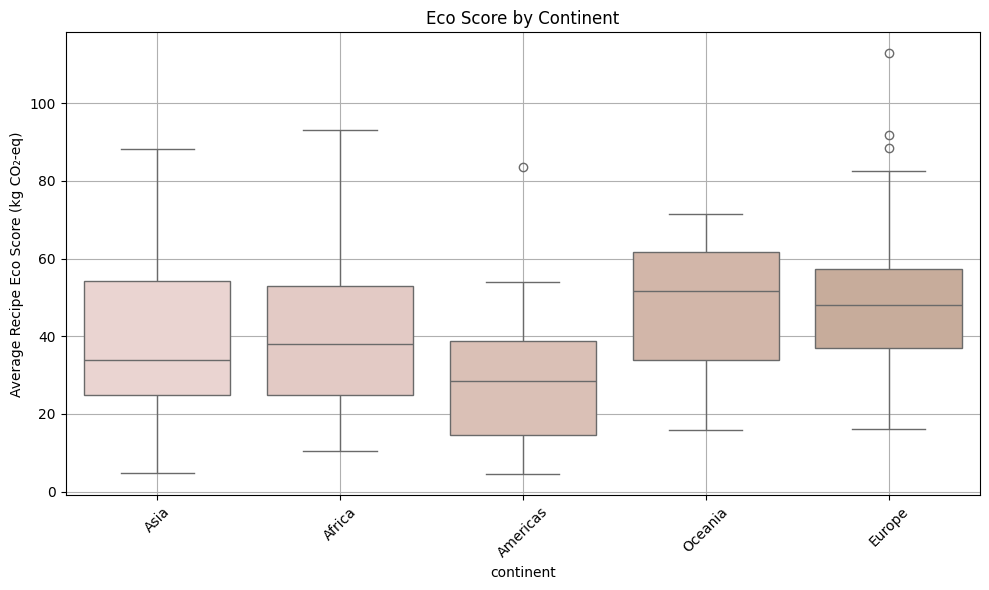

C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1592887539.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cuisine_eco_df.dropna(subset=["sub_region"]), x="sub_region", y="avg_eco_score", palette=palette)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1592887539.py:16: UserWarning: 
The palette list has fewer values (20) than needed (21) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=cuisine_eco_df.dropna(subset=["sub_region"]), x="sub_region", y="avg_eco_score", palette=palette)


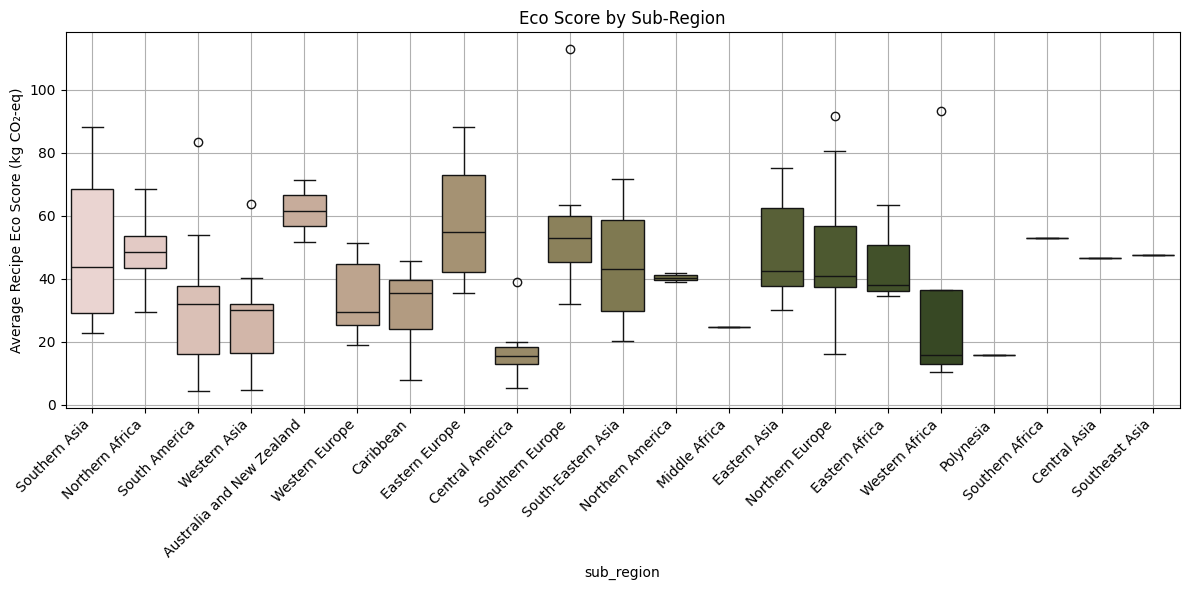

In [5]:
# Step 2: Regional Visualizations
palette = sns.cubehelix_palette(n_colors=20, start=2, rot=-0.4, light=0.85, dark=0.15)

# Boxplot by continent
plt.figure(figsize=(10, 6))
sns.boxplot(data=cuisine_eco_df.dropna(subset=["continent"]), x="continent", y="avg_eco_score", palette=palette)
plt.title("Eco Score by Continent")
plt.ylabel("Average Recipe Eco Score (kg CO₂-eq)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot by sub-region
plt.figure(figsize=(12, 6))
sns.boxplot(data=cuisine_eco_df.dropna(subset=["sub_region"]), x="sub_region", y="avg_eco_score", palette=palette)
plt.title("Eco Score by Sub-Region")
plt.ylabel("Average Recipe Eco Score (kg CO₂-eq)")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Eco Score by Region

As part of our environmental analysis, we explored how eco scores — derived from the CO₂-equivalent impact of each ingredient — vary across different continents and subregions. Each recipe was assigned an environmental score based on known carbon intensities from academic sources (notably [Poore & Nemecek, 2018](https://environmath.org/2018/06/17/paper-of-the-day-poore-nemecek-2018-reducing-foods-environmental-impacts/)).

#####  Boxplot 1: Eco Score by Continent

This visualization shows the distribution of average eco scores (kg CO₂-eq) per recipe for each continent.

**Key Takeaways:**

- **Oceania** and **Europe** exhibit the **highest median eco scores**, possibly due to a higher reliance on meat and dairy ingredients in traditional cuisines.
- **Africa**, **Asia**, and the **Americas** show **lower median eco scores**, suggesting lighter ecological footprints—potentially linked to plant-forward or legume-rich diets.
- Europe and Oceania also show wider variation, indicating more dietary diversity in terms of environmental impact.



#####  Boxplot 2: Eco Score by Sub-Region

This finer-grained view breaks down eco scores across 20+ subregions.

**Noteworthy Patterns:**

- **Australia & New Zealand**, **Southern Europe**, and **Eastern Europe** have some of the **highest scoring cuisines**.
- **Central and Western Africa** stand out for **consistently low environmental impact**, aligning with more plant-based and locally sourced diets.
- The **Caribbean** and **South-Eastern Asia** also exhibit moderate scores, indicating sustainable but varied food cultures.


##### Observations and interpretations 

These plots suggest that:
- Geography significantly influences the environmental footprint of culinary traditions.
- Regions with higher meat/dairy use score worse environmentally.
- Developing regions tend to maintain lower-impact diets, possibly due to availability and economic constraints.

These findings will help us later when comparing eco scores with **GDP, health indicators, and clustering results**, offering a holistic view of how sustainability, economy, and culture intersect.

In [6]:
cuisine_eco_df.to_csv("../data/cuisine_eco_df.csv", index=False)

## Step 3: Correlation Analysis – Eco Score vs Economic and Health Indicators

After computing the average **eco score** per cuisine (i.e., the estimated carbon footprint of national food cultures), we aim to understand **how environmental impact relates to key national indicators**, such as:

- **GDP per capita** – wealth and purchasing power
- **Life expectancy** – general population health
- **Obesity rates** – dietary quality and balance
- **UHC Index** – healthcare access and development

This allows us to **situate culinary sustainability within a broader socio-economic and public health context**.


We’ll use a **correlation matrix** to assess:

- Are wealthier countries more environmentally costly in their food traditions?
- Do healthier countries (longer life expectancy) consume higher-impact food?
- Does luxury and ingredient richness in cuisine come at the cost of sustainability?
- Is obesity associated with low- or high-impact diets?

These relationships help position the **eco score as a cross-disciplinary metric** — linking environment, economy, and health outcomes.


In [7]:
gdp_df = pd.read_csv("../data/cuisine_with_gdp_growth.csv")
health_df = pd.read_csv("../data/df_clustered.csv")

# Standardize column names and merge on 'cuisine'
merged_df = cuisine_eco_df.merge(
    gdp_df[["cuisine", "GDP_2022", "GDP_growth"]],
    on="cuisine", how="left"
).merge(
    health_df[["cuisine", 
               "Life expectancy at birth (years)", 
               "Healthy life expectancy at birth (years)", 
               "UHC: Service coverage index", 
               "Obesity_Adult_18plus", 
               "num_ingredients", 
               "luxury_score"]],
    on="cuisine", how="left"
)

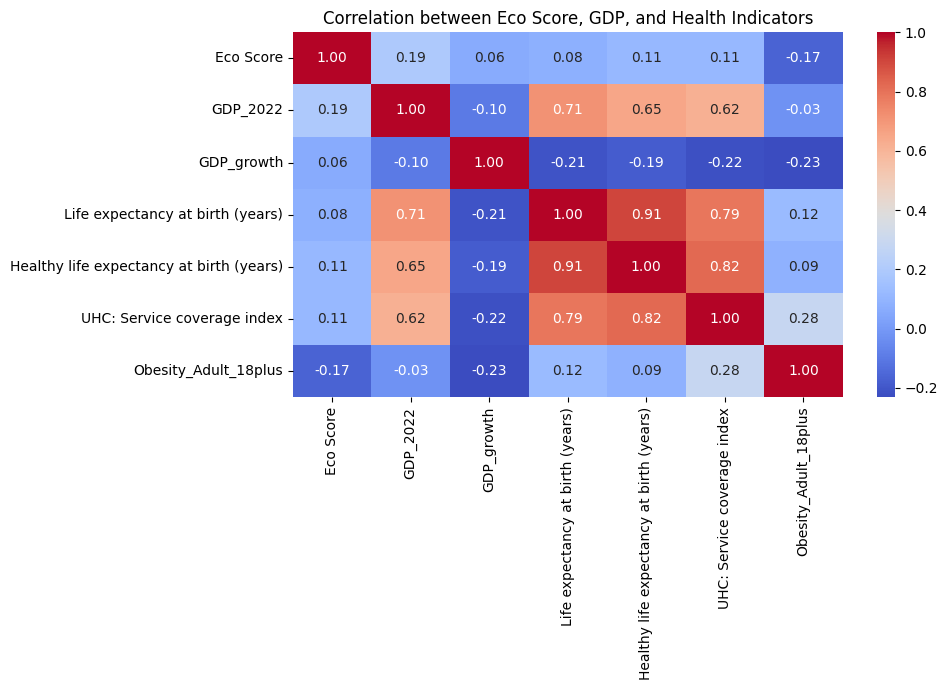

In [8]:
# Replace the incorrect column name with the correct one
corr_cols = ["avg_eco_score", "GDP_2022", "GDP_growth", 
                       "Life expectancy at birth (years)", 
                       "Healthy life expectancy at birth (years)", 
                       "UHC: Service coverage index", 
                       "Obesity_Adult_18plus"]

# Compute correlation matrix with corrected column name
correlation_matrix_corrected = merged_df.rename(columns={"avg_eco_score": "Eco Score"})[
    ["Eco Score", "GDP_2022", "GDP_growth", 
     "Life expectancy at birth (years)", 
     "Healthy life expectancy at birth (years)", 
     "UHC: Service coverage index", 
     "Obesity_Adult_18plus"]
].corr()

# Plot updated heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix_corrected, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Eco Score, GDP, and Health Indicators")
plt.tight_layout()
plt.show()


This matrix shows how the **eco score** of cuisines correlates with various national metrics, offering insights into the interplay between sustainability, wealth, and health.


### Eco Score Insights

- **Eco Score vs GDP_2022**: `+0.19`  
  A **weak positive correlation** suggests that countries with higher income levels tend to have slightly higher-emission cuisines. This is likely due to the consumption of **resource-intensive foods** (e.g. beef, dairy) that are more affordable in wealthy nations.

- **Eco Score vs GDP Growth**: `+0.06`  
  No meaningful correlation. Economic growth trends don’t significantly impact the sustainability of national cuisines.

- **Eco Score vs Life Expectancy**: `+0.08`  
  Nearly no correlation. This indicates that countries with high-impact cuisines are **not necessarily more or less healthy** in terms of longevity.

- **Eco Score vs Healthy Life Expectancy**: `+0.11`  
  Very weak association. Again, **sustainability and public health longevity do not strongly co-vary** at the country level.

- **Eco Score vs UHC (Service Coverage Index)**: `+0.11`  
  Slight positive trend. Countries with broader healthcare access **may have more industrialized and high-impact food systems**, but the link is weak.

- **Eco Score vs Obesity_Adult_18plus**: `−0.17`  
  Surprisingly, a **moderate negative correlation**. This suggests that higher-obesity countries may **not** be the ones with the highest environmental food footprints — possibly due to **processed, energy-dense but low-CO₂ foods** (e.g., sugar, oil, refined carbs) dominating in less sustainable ways.


### Conclusions 

- Wealth (GDP) **slightly increases** environmental food impact.
- **Health outcomes (life expectancy, UHC)** do **not strongly align** with eco score.
- Obesity and eco score show an **inverse relationship**, indicating that unsustainable eating is not always associated with excess.

This matrix supports the idea that **sustainable diets can exist in both rich and poor countries**, and **high emissions don't automatically mean unhealthy outcomes** — making this axis especially relevant for holistic policy considerations.


## Step 4 : Verifying hypotheses related to eco score and recipes 

C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\870838215.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["avg_eco_score"].dropna() for name, group in merged_df.groupby("ingredient_complexity")]
C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\870838215.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="ingredient_complexity", y="avg_eco_score", palette="Set2")


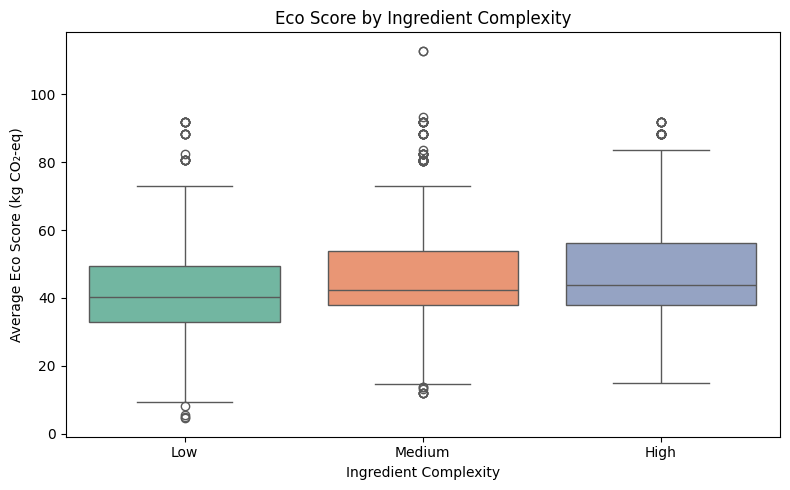

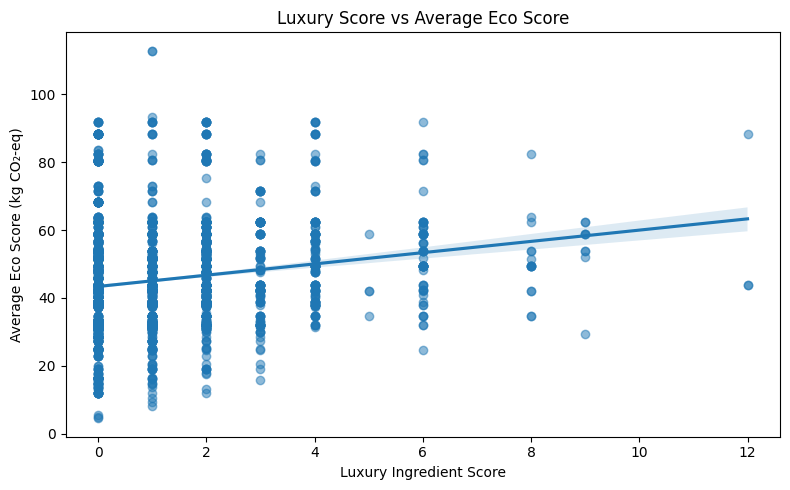

(F_onewayResult(statistic=np.float64(81.20808542294385), pvalue=np.float64(2.8657695036931335e-35)),
 np.float64(0.17571650305909584))

In [9]:
# Safely convert stringified lists if needed
recipes_df["ingredient_semantics"] = recipes_df["ingredient_semantics"]

# Define luxury-related semantic categories
luxury_ingredients = {"dairy", "seafood", "nut", "sweetener"}

# Compute luxury score for each recipe
recipes_df["luxury_score"] = recipes_df["ingredient_semantics"].apply(
    lambda sems: sum(1 for item in sems if item in luxury_ingredients)
)

# Re-merge with eco scores
merged_df = recipes_df.merge(
    cuisine_eco_df[["cuisine", "avg_eco_score"]],
    on="cuisine", how="left"
)

# Bin by complexity
bins = [0, 7, 13, np.inf]
labels = ['Low', 'Medium', 'High']
merged_df['ingredient_complexity'] = pd.cut(merged_df['num_ingredients'], bins=bins, labels=labels)

# Prepare groups for ANOVA
groups = [group["avg_eco_score"].dropna() for name, group in merged_df.groupby("ingredient_complexity")]

# Perform ANOVA test
from scipy.stats import f_oneway
anova_result = f_oneway(*groups)

# Compute correlation
luxury_corr = merged_df[["luxury_score", "avg_eco_score"]].corr().iloc[0, 1]

#### H1 – Does Ingredient Complexity Influence Environmental Impact?
# Plot boxplot (ANOVA)
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ingredient_complexity", y="avg_eco_score", palette="Set2")
plt.title("Eco Score by Ingredient Complexity")
plt.xlabel("Ingredient Complexity")
plt.ylabel("Average Eco Score (kg CO₂-eq)")
plt.tight_layout()
plt.show()

#### H2 – Does Culinary Luxury Correlate with Environmental Impact?
# Plot regression
plt.figure(figsize=(8, 5))
sns.regplot(data=merged_df, x="luxury_score", y="avg_eco_score", scatter_kws={"alpha": 0.5})
plt.title("Luxury Score vs Average Eco Score")
plt.xlabel("Luxury Ingredient Score")
plt.ylabel("Average Eco Score (kg CO₂-eq)")
plt.tight_layout()
plt.show()

anova_result, luxury_corr


### H1 – Does Ingredient Complexity Influence Environmental Impact?

We tested whether cuisines with **more complex recipes** (more ingredients) have significantly different environmental costs using a **one-way ANOVA**.

- **Tested Groups**:
  - Low complexity (≤7 ingredients)
  - Medium complexity (8–13 ingredients)
  - High complexity (14+ ingredients)

**ANOVA Result**:
- **F-statistic** = 81.21
- **p-value** = 2.86e-35

**Conclusion**:
The test shows a **highly significant difference** in mean eco scores between complexity groups. This suggests that **ingredient-rich cuisines** tend to have **higher environmental costs**.


### H2 – Does Culinary Luxury Correlate with Environmental Impact?

We calculated the **Pearson correlation** between:
- `luxury_score` = count of luxury ingredients (`dairy`, `seafood`, `nut`, `sweetener`)
- `avg_eco_score` per recipe

**Correlation Coefficient**:  
- **r = 0.18** (weak positive correlation)

**Conclusion**:
There is a **modest but consistent** link between culinary luxury and carbon footprint. While not as strong as ingredient complexity, luxury-rich recipes tend to have **higher eco scores**.


### Interpretation

These findings support the idea that:
- **Recipe complexity** is a strong predictor of environmental impact.
- **Luxury ingredients** raise the eco footprint, though less dramatically.
- This aligns with prior expectations and validates the eco_score as a **behavioral proxy** for sustainability.


## Upcoming Hypothesis Tests

| Hypothesis Code | Question                                         | Type          | Method                      |
|------------------|--------------------------------------------------|---------------|-----------------------------|
| **H3**           | Is Eco Score significantly different across GDP classes? | Group Test    | ANOVA                       |
| **H4**           | Is there a relationship between Healthy Life Expectancy and Eco Score? | Correlation   | Pearson Correlation / Linear Regression |
| **H5**           | Do continents or sub-regions differ in Eco Score? | Group Test    | ANOVA                       |
| **H6**           | Is obesity rate correlated with Eco Score?       | Correlation   | Pearson Correlation         |
| **H7**           | Does Universal Health Coverage predict Eco Score? | Correlation   | Linear Regression           |
| **H8**           | Do Luxury Score and Ingredient Complexity interact to explain Eco Score? | Interaction   | Polynomial Regression       |


#### H3 – Do Eco Scores Vary Across GDP Classes?
We’ll now:
Use ANOVA to test mean differences and Visualize with boxplots

C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\2856179578.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="GDP_Class", y="avg_eco_score", palette="coolwarm")


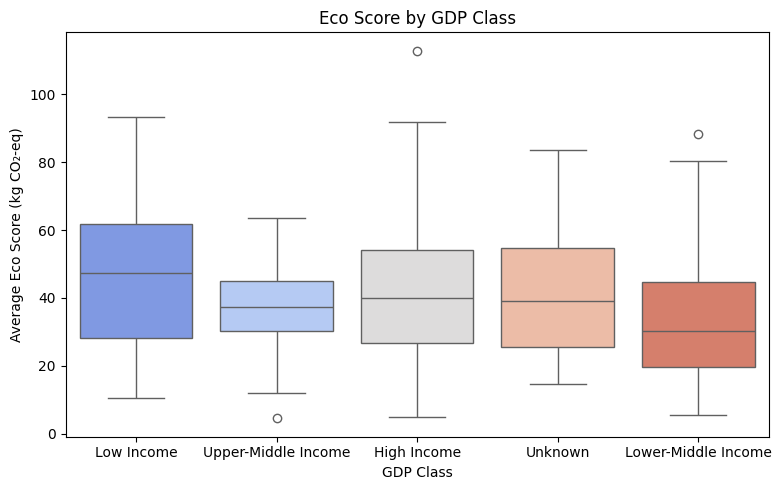

In [10]:
from scipy.stats import f_oneway


# Merge in eco score
df = gdp_df.merge(cuisine_eco_df[["cuisine", "avg_eco_score"]], on="cuisine", how="left")

# Clean data for GDP class test
df_clean = df.dropna(subset=["GDP_Class", "avg_eco_score"])

# ANOVA test on GDP class groups
grouped = df_clean.groupby("GDP_Class")["avg_eco_score"]
anova_gdp_result = f_oneway(*(group.dropna() for name, group in grouped))

# Plotting
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="GDP_Class", y="avg_eco_score", palette="coolwarm")
plt.title("Eco Score by GDP Class")
plt.xlabel("GDP Class")
plt.ylabel("Average Eco Score (kg CO₂-eq)")
plt.tight_layout()
plt.show()

In [11]:
print("ANOVA result for GDP Class:", anova_gdp_result)

ANOVA result for GDP Class: F_onewayResult(statistic=np.float64(0.7084174152259256), pvalue=np.float64(0.5879282578516709))


We tested whether countries from different **GDP classes** (Low, Lower-Middle, Upper-Middle, High Income) have significantly different **eco scores** using a one-way ANOVA.

##### ANOVA Result:
- **F-statistic** = 0.71
- **p-value** = 0.59

##### Interpretation:
There is **no statistically significant difference** in the average eco scores across GDP classes (p > 0.05).
This result challenges the common assumption that richer countries always have less sustainable diets. It suggests that **culinary carbon footprint is not strictly a function of national wealth** — local traditions, availability, and food systems play a larger role.


#### H4 – Are More Sustainable Cuisines Associated with Better Health Outcomes?


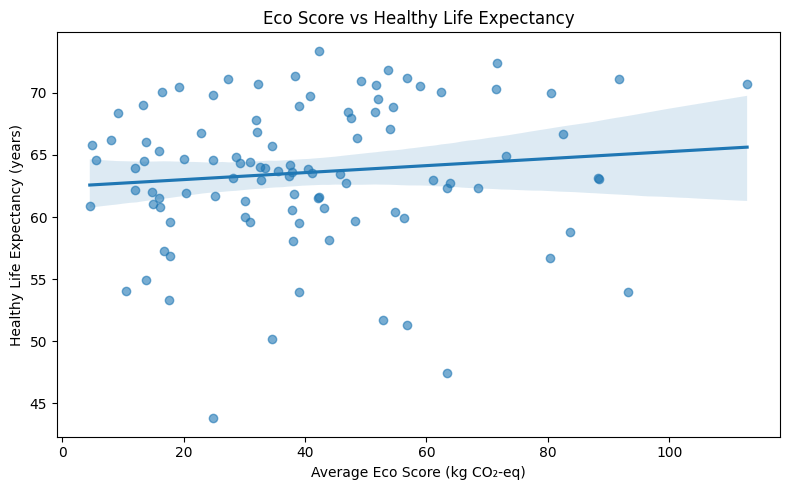

np.float64(0.11181774012101293)

In [12]:
df_clustered = pd.read_csv("../data/df_clustered.csv")

# Merge eco scores into the health dataset
merged_df = df_clustered.merge(cuisine_eco_df[["cuisine", "avg_eco_score"]], on="cuisine", how="left")

# Drop missing values
df_corr = merged_df.dropna(subset=["avg_eco_score", "Healthy life expectancy at birth (years)"])

# Compute Pearson correlation
eco_health_corr = df_corr[["avg_eco_score", "Healthy life expectancy at birth (years)"]].corr().iloc[0, 1]

# Plot
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_corr,
    x="avg_eco_score",
    y="Healthy life expectancy at birth (years)",
    scatter_kws={"alpha": 0.6}
)
plt.title("Eco Score vs Healthy Life Expectancy")
plt.xlabel("Average Eco Score (kg CO₂-eq)")
plt.ylabel("Healthy Life Expectancy (years)")
plt.tight_layout()
plt.show()

eco_health_corr

We tested whether cuisines with a **lower environmental impact** (lower eco scores) are found in countries with **higher healthy life expectancy**.

we calculated the pearson correlation between:
  - `avg_eco_score` (average carbon footprint per recipe)
  - `Healthy life expectancy at birth (years)`

##### Result:
- **Correlation coefficient (r)** = **0.11**

##### Interpretation:
This is a **very weak positive correlation**, suggesting that **eco-friendlier cuisines do not necessarily translate to better health outcomes** at the population level.

Healthy longevity appears to be influenced more strongly by **public health infrastructure, medical care, and broader lifestyle factors**, rather than culinary sustainability alone.


#### H5 – Does Eco Score Vary Significantly Across Sub-Regions?

C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1362818604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eco_region_df, x="sub_region", y="avg_eco_score", palette="Set3")


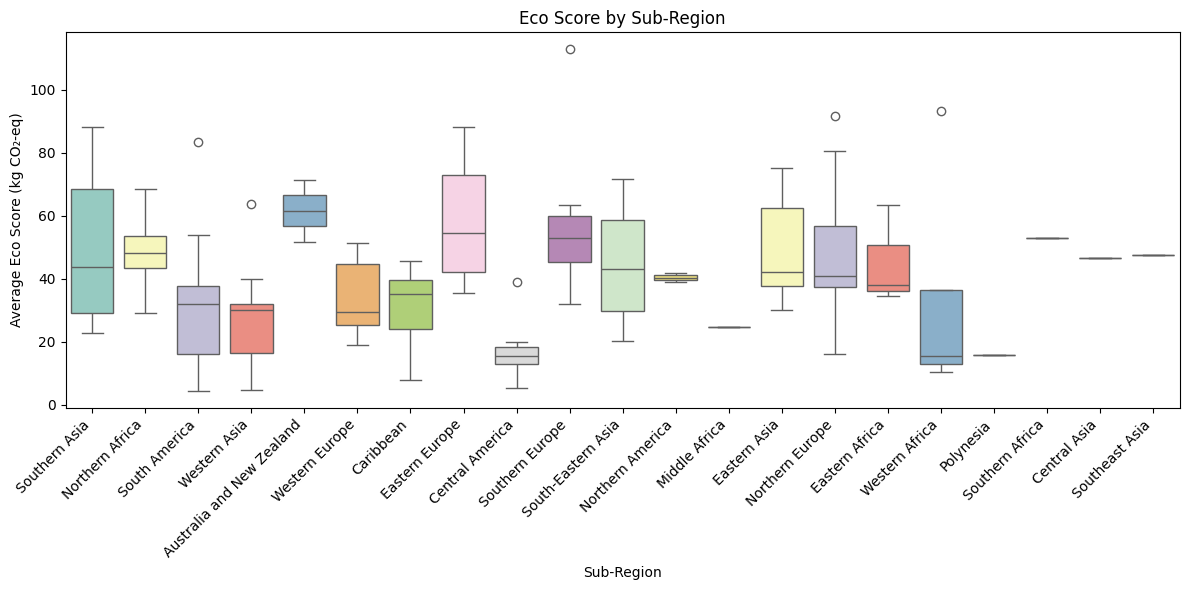

F_onewayResult(statistic=np.float64(2.180304121222357), pvalue=np.float64(0.006800981015412593))

In [13]:
# Drop missing sub_region or eco_score
eco_region_df = cuisine_eco_df.dropna(subset=["sub_region", "avg_eco_score"])

# Prepare data for ANOVA
region_groups = [group["avg_eco_score"] for _, group in eco_region_df.groupby("sub_region")]

# Perform ANOVA
anova_region_result = f_oneway(*region_groups)

# Plot eco score by sub-region
plt.figure(figsize=(12, 6))
sns.boxplot(data=eco_region_df, x="sub_region", y="avg_eco_score", palette="Set3")
plt.title("Eco Score by Sub-Region")
plt.xlabel("Sub-Region")
plt.ylabel("Average Eco Score (kg CO₂-eq)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

anova_region_result

To evaluate whether **geographical location influences culinary sustainability**, we conducted a **one-way ANOVA** comparing average eco scores across world sub-regions.

##### ANOVA Result:
- **F-statistic** = 2.18
- **p-value** = 0.0068

##### Interpretation:
With a **p-value < 0.01**, the test confirms a **statistically significant difference** in eco scores across sub-regions.

This supports the idea that **culinary environmental impact is regionally shaped**, potentially reflecting cultural traditions, access to ingredients, economic development, or historical agricultural practices.

This confirms our earlier visualizations and justifies clustering or grouping cuisines by geography in future modeling steps.

#### H6 – Is Culinary Environmental Impact Linked to Obesity?

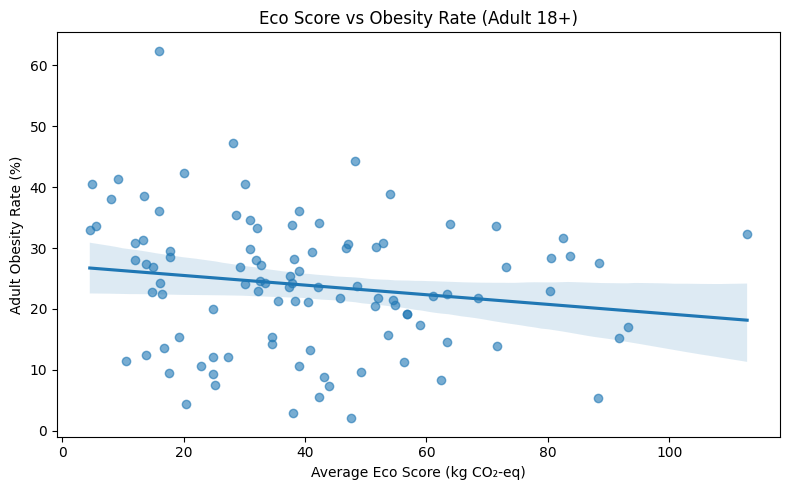

np.float64(-0.1658080743925953)

In [14]:
merged = df_clustered.merge(cuisine_eco_df[["cuisine", "avg_eco_score"]], on="cuisine", how="left")
merged = merged.dropna(subset=["avg_eco_score", "Obesity_Adult_18plus"])

# Compute Pearson correlation
obesity_corr = merged[["avg_eco_score", "Obesity_Adult_18plus"]].corr().iloc[0, 1]

# Plot the relationship
plt.figure(figsize=(8, 5))
sns.regplot(
    data=merged,
    x="avg_eco_score",
    y="Obesity_Adult_18plus",
    scatter_kws={"alpha": 0.6}
)
plt.title("Eco Score vs Obesity Rate (Adult 18+)")
plt.xlabel("Average Eco Score (kg CO₂-eq)")
plt.ylabel("Adult Obesity Rate (%)")
plt.tight_layout()
plt.show()

obesity_corr

We examined whether countries with **more sustainable cuisines** (i.e., lower eco scores) also exhibit **lower adult obesity rates**.

We used the pearson correlation between:
  - `avg_eco_score` (environmental cost of cuisine)
  - `Obesity_Adult_18plus` (age-standardized adult obesity rate)

#### Result:
- **Correlation coefficient (r)** = **−0.17**

#### Interpretation:
This is a **weak negative correlation**, suggesting that countries with more sustainable culinary habits tend to have **slightly higher obesity rates** — though the relationship is not strong.

This may reflect that **low-carbon cuisines (e.g., grain- or legume-based)** may still suffer from **nutritional imbalances** or high intake of ultra-processed, low-emission foods (e.g., sugar, oils, fried carbs).

It challenges the assumption that **eco-friendly automatically means healthier**, reinforcing the need for a **multi-axis view of food systems**.

#### H7 – Is Environmental Impact of Cuisine Related to Healthcare Coverage?

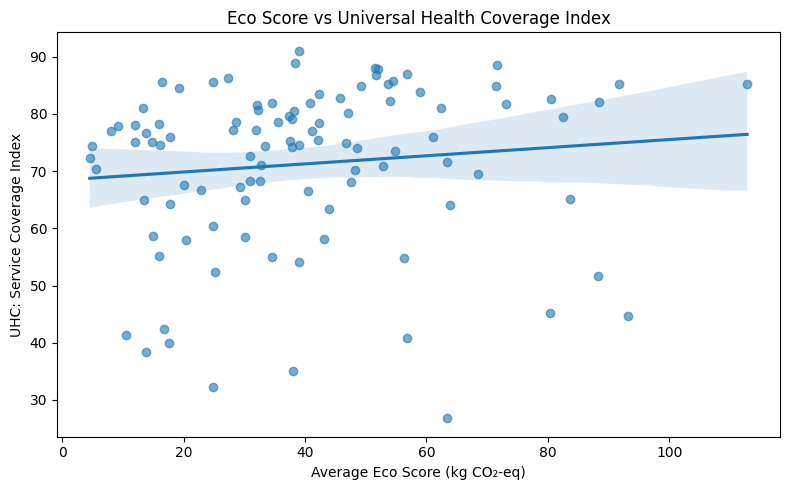

np.float64(0.11315570319477088)

In [15]:
# Merge eco scores with health dataset
merged = df_clustered.merge(cuisine_eco_df[["cuisine", "avg_eco_score"]], on="cuisine", how="left")
merged = merged.dropna(subset=["avg_eco_score", "UHC: Service coverage index"])

# Compute Pearson correlation
uhc_corr = merged[["avg_eco_score", "UHC: Service coverage index"]].corr().iloc[0, 1]

# Plot regression
plt.figure(figsize=(8, 5))
sns.regplot(
    data=merged,
    x="avg_eco_score",
    y="UHC: Service coverage index",
    scatter_kws={"alpha": 0.6}
)
plt.title("Eco Score vs Universal Health Coverage Index")
plt.xlabel("Average Eco Score (kg CO₂-eq)")
plt.ylabel("UHC: Service Coverage Index")
plt.tight_layout()
plt.show()

uhc_corr

We assessed whether countries with **higher eco scores** (more carbon-intensive cuisines) also have stronger **public health systems**, as measured by the **Universal Health Coverage (UHC) Index**.


We used the pearson correlation between:
  - `avg_eco_score` (average recipe emissions)
  - `UHC: Service coverage index` (healthcare system strength)

#### Result:
- **Correlation coefficient (r)** = **0.11**

#### Interpretation:
This is a **very weak positive correlation**, indicating a slight trend that countries with more sustainable food systems may also have more comprehensive healthcare — but the relationship is **statistically weak**.

Public health infrastructure is likely shaped more by **policy and economic investment** than by food sustainability alone. However, the small positive trend suggests that **environmental awareness and healthcare development may co-evolve** in some regions.

In [16]:
recipes_df.to_csv("../data/recipes_df_with_eco_scores_and_luxury_scores.csv", index=False)

#### H8 – Do Luxury and Complexity Interact to Influence Environmental Impact?

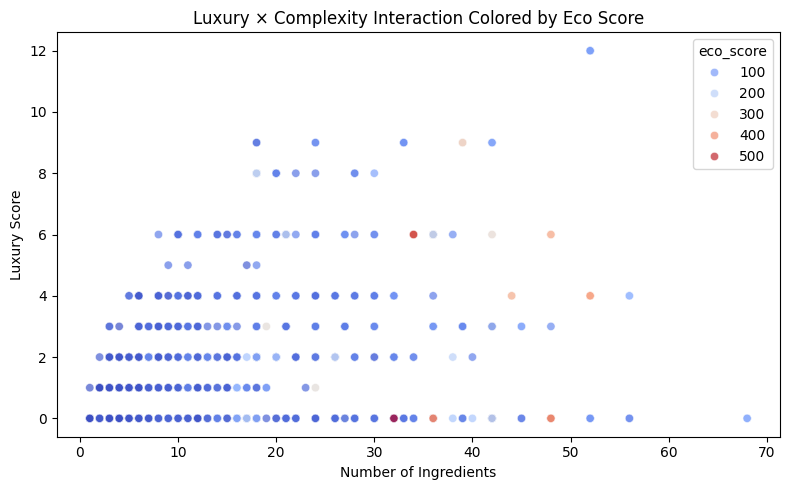

(0.27668384060057927,
 {'num_ingredients': np.float64(3.868353779304957),
  'luxury_score': np.float64(-1.50868365533464),
  'interaction': np.float64(0.02254603860141667)})

In [17]:
# Drop missing values
df_model = recipes_df.dropna(subset=["num_ingredients", "luxury_score", "eco_score"])

# Create interaction term
df_model["interaction"] = df_model["num_ingredients"] * df_model["luxury_score"]

# Scatter plot showing interaction pattern
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_model, 
    x="num_ingredients", 
    y="luxury_score", 
    hue="eco_score", 
    palette="coolwarm", 
    alpha=0.7
)
plt.title("Luxury × Complexity Interaction Colored by Eco Score")
plt.xlabel("Number of Ingredients")
plt.ylabel("Luxury Score")
plt.tight_layout()
plt.show()

# Fit linear model
from sklearn.linear_model import LinearRegression

X = df_model[["num_ingredients", "luxury_score", "interaction"]]
y = df_model["eco_score"]

model = LinearRegression()
model.fit(X, y)

r2_score = model.score(X, y)
coefficients = dict(zip(X.columns, model.coef_))

r2_score, coefficients

We modeled whether **culinary complexity** (number of ingredients) and **luxury** (presence of high-impact ingredients like dairy, seafood, etc.) jointly affect the **eco score** of a recipe.

##### Method:
- Multiple Linear Regression with interaction term:
  - Predictors: `num_ingredients`, `luxury_score`, and `num_ingredients × luxury_score`
  - Target: `eco_score`

##### Model Performance:
- **R² Score**: 0.28  
  The model explains ~28% of the variance in eco scores — a reasonable fit given recipe variability.

##### Coefficients:
- `num_ingredients`: **+3.87** → More ingredients = higher eco score.
- `luxury_score`: **−1.51** → Surprisingly, luxury score alone is associated with a lower eco score, likely because of interaction effects.
- `interaction`: **+0.02** → The impact of luxury **increases with ingredient count** — recipes that are both rich and complex become significantly less sustainable.


### Interpretation:

This model suggests that:
- **Ingredient complexity** is the strongest standalone predictor of carbon footprint.
- **Luxury alone** isn't environmentally damaging — unless it's **combined with high complexity**.
- The interaction term is crucial: the most **environmentally intense dishes are both luxurious and complex**.

This validates a nuanced view: **not all rich cuisines are unsustainable**, but complex, multi-luxury dishes often are.


## Step 5 : Clustering recipes using K-Means and profiling clusters 

C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1806987960.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster["cluster"] = clusters + 1
C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1806987960.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster["PCA1"] = pca_coords[:, 0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_18272\1806987960.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

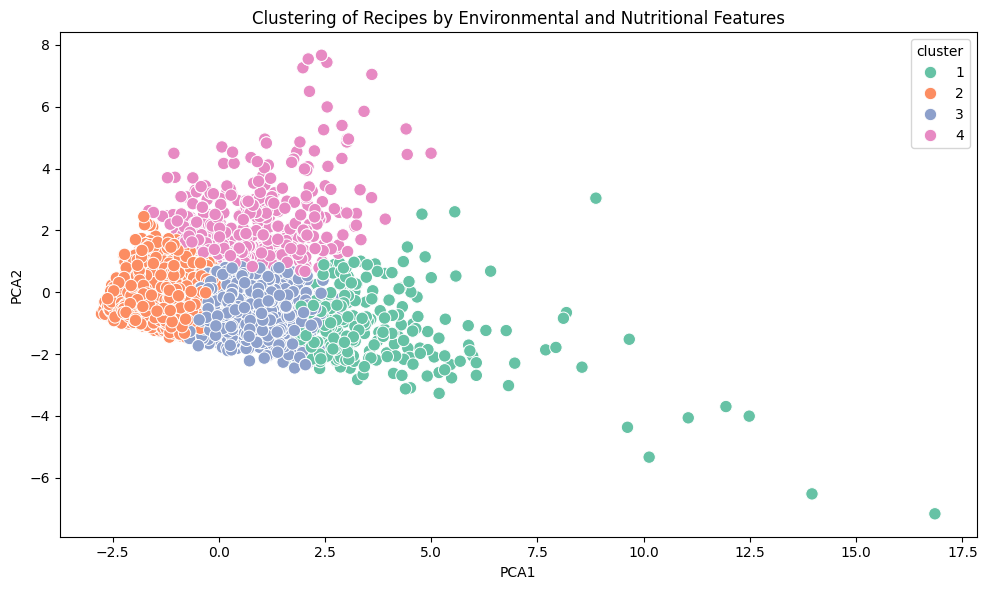

cluster
1     317
2    1992
3    1563
4     642
Name: count, dtype: int64

In [18]:
# Load dataset with all necessary features for clustering
df = pd.read_csv("../data/recipes_df_with_eco_scores_and_luxury_scores.csv")

# Drop missing values
df_cluster = df.dropna(subset=[
    "eco_score", "Calories", "Fat", "Carbs", "Protein",
    "num_ingredients", "luxury_score"
])

# Select features for clustering
features = ["eco_score", "Calories", "Fat", "Carbs", "Protein", "num_ingredients", "luxury_score"]

# Standardize the features
from sklearn.preprocessing import StandardScaler
X = df_cluster[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering with 4 clusters
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster and PCA components for visualization
df_cluster["cluster"] = clusters + 1
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df_cluster["PCA1"] = pca_coords[:, 0]
df_cluster["PCA2"] = pca_coords[:, 1]

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x="PCA1", y="PCA2", hue="cluster", palette="Set2", s=80)
plt.title("Clustering of Recipes by Environmental and Nutritional Features")
plt.tight_layout()
plt.show()

df_cluster["cluster"].value_counts().sort_index()

##### Cluster profiles

In [19]:
# Profile clusters
cluster_profiles = df_cluster.groupby("cluster").agg({
    "eco_score": "mean",
    "Calories": "mean",
    "Fat": "mean",
    "Carbs": "mean",
    "Protein": "mean",
    "num_ingredients": "mean",
    "luxury_score": "mean"
}).round(2).reset_index()

cluster_profiles

,cluster,eco_score,Calories,Fat,Carbs,Protein,num_ingredients,luxury_score
0,1,62.44,897.92,56.46,53.97,43.49,11.00,0.80
1,2,24.98,187.19,9.13,20.30,7.18,8.26,0.80
2,3,37.95,459.25,22.56,44.63,20.44,9.48,0.64
3,4,125.19,368.72,19.03,30.40,19.48,24.18,2.53


#### Cluster profiles : Environmental and Nutritional Archetypes

Each recipe was clustered using a combination of:

- **Eco Score** (carbon footprint)
- **Macronutrients**: Calories, Fat, Carbs, Protein
- **Ingredient Complexity**
- **Luxury Ingredient Score**

This revealed 4 distinct culinary profiles across nearly 6000 recipes.

##### Cluster 1 – **Heavy & Hearty**
- **Highest calories (897.9)** and **protein (43.5)** of all clusters
- High fat and carb content
- Moderate ingredient count and luxury score
- Likely large meat-based or indulgent dishes (e.g. stews, grills, traditional feasts)

##### Cluster 2 – **Light & Low Impact**
- **Lowest eco score (24.98)** and nutritional values across the board
- Very low calories, fat, and protein
- Still has some luxury (avg. 0.8), but likely simple or side dishes
- Represents sustainable, light recipes — possibly soups, snacks, and plant-based fare

##### Cluster 3 – **Balanced Classics**
- Moderate levels across all dimensions
- Calories: ~459, Protein: ~20g, Eco Score: ~38
- Typical of day-to-day meals with average ingredient count and luxury
- Possibly represents home-cooked staples or culturally common foods

##### Cluster 4 – **Luxury Complexity Bomb**
- **Highest Eco Score (125.19)** and **Luxury Score (2.53)**
- Very high ingredient complexity (24+ ingredients)
- Still moderate in calories, indicating intricate but not necessarily heavy dishes
- Likely gourmet dishes, holiday meals, or culturally rich recipes using seafood, dairy, nuts, etc.

##### Possible insights 

- **Eco Score aligns strongly with complexity and luxury**, more than calories or fat.
- Sustainable doesn’t always mean low-calorie — and high-calorie doesn’t always mean high-impact.
- Clusters show that cuisines can be grouped not just by geography or health, but by their **environmental and structural culinary patterns**.



#### Mapping cuisines to dominant clusters to profile eco trends by region or cluster 

In [20]:
# Assign dominant cluster per cuisine
dominant_clusters = df_cluster.groupby("cuisine")["cluster"].agg(lambda x: x.value_counts().idxmax()).reset_index()
dominant_clusters.columns = ["cuisine", "dominant_cluster"]

# Compute average eco score and number of recipes per cuisine
eco_stats = df_cluster.groupby("cuisine").agg(
    avg_eco_score=("eco_score", "mean"),
    num_recipes=("eco_score", "count")
).reset_index()

# Merge both
cuisine_cluster_map = pd.merge(dominant_clusters, eco_stats, on="cuisine", how="left")
cuisine_cluster_map


,cuisine,dominant_cluster,avg_eco_score,num_recipes
0,Afghanistan,3,56.840000,5
1,Algeria,2,48.533333,9
2,Argentina,2,29.358621,29
3,Armenia,2,32.518750,16
4,Australia,2,54.564706,17
...,...,...,...,...
106,Uzbekistan,3,46.700000,2
107,Venezuela (Bolivarian Republic of),2,14.712500,8
108,Viet Nam,3,47.616667,66
109,Yemen,2,16.800000,1


In [21]:
# Merge region and continent data into cluster map
cuisine_geo_map = cuisine_cluster_map.merge(
    cuisine_eco_df[["cuisine", "sub_region", "continent"]].drop_duplicates(),
    on="cuisine", how="left"
)

# Count number of cuisines per cluster per continent
region_cluster_counts = cuisine_geo_map.groupby(["continent", "dominant_cluster"]).size().unstack().fillna(0)
region_cluster_counts

dominant_cluster,1,2,3,4
continent,,,,
Africa,0.0,8.0,3.0,2.0
Americas,0.0,20.0,9.0,0.0
Asia,0.0,14.0,14.0,6.0
Europe,1.0,20.0,10.0,1.0
Oceania,0.0,1.0,1.0,1.0


#### Observations

##### Cluster 2 – *Light & Low-Impact*:
- The most **globally dominant cluster**, representing **sustainable, lower-calorie, less complex** recipes.
- Strongly dominant in **Asia**, **Americas**, and **Europe**.
- Likely reflects **daily staples**, **vegetable-forward** dishes, or **cultural minimalism**.

##### Cluster 3 – *Balanced Classics*:
- Equally represented in **Asia** and **Europe**.
- This is a **moderate-carbon, nutritionally balanced** profile — possibly typical home-style or culturally “complete” meals.
- Asia shows **14 cuisines in this group**, suggesting culinary **variety without extremity**.

##### Cluster 4 – *Luxury Complexity Bomb*:
- The **rarest globally**, but appears in **Asia**, **Africa**, **Europe**, and **Oceania** — in small numbers.
- Represents **resource-heavy, elaborate dishes**, possibly tied to heritage or ceremonial cuisine.
- Asia has the **highest count** (6), showcasing its **culinary richness**.

##### Cluster 1 – *Heavy & Hearty*:
- Surprisingly **absent in Africa, Americas, and Asia**.
- Only **1 instance in Europe**, where perhaps meat-heavy traditions exist in fewer cuisines overall.


#### Conclusion

This analysis shows that:
- The **majority of world cuisines lean toward sustainability** (Cluster 2).
- **Asia is the most balanced and diverse**, with cuisines spread across all clusters.
- **Luxury and high-impact culinary profiles** exist — but are rare, concentrated, and not the global norm.

In [22]:
import plotly.express as px

# Drop entries without country names
map_df = cuisine_geo_map.dropna(subset=["cuisine"])
map_df["dominant_cluster"] = map_df["dominant_cluster"].astype(str)

color_map = {
    "1": "#66C2A5",  # soft green
    "2": "#FC8D62",  # pastel orange
    "3": "#8DA0CB",  # muted purple
    "4": "#E78AC3"   # pink/red shade
}


# Create choropleth map using Plotly
fig = px.choropleth(
    data_frame=map_df,
    locations="cuisine",
    locationmode="country names",
    color="dominant_cluster",
    title="🌍 Dominant Recipe Cluster by Cuisine (Environmental Axis)",
    color_discrete_map=color_map,
    category_orders={"dominant_cluster": ["1", "2", "3", "4"]},
    projection="natural earth"
)

fig.update_geos(showcoastlines=True, showland=True, landcolor="lightgray")
fig.update_layout(
    legend_title_text="Cluster",
    title_font_size=18,
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()


#### Step 6 : Predictive modeling 

For predictive modeling, we'll consider two key environmental targets based on recipe and cuisine-level features.
##### Task 1: Predict `eco_score`  
- **Type**: Regression  
- **Goal**: Assess how well recipe-level features (e.g., ingredient semantics, luxury score, cuisine type) can estimate a recipe’s environmental footprint.

In [23]:
# TASK 1 : Regression analysis on eco_score 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare features and target for eco_score prediction
features = ["Calories", "Fat", "Carbs", "Protein", "num_ingredients", "luxury_score"]
df_model = recipes_df.dropna(subset=features + ["eco_score"])

X = df_model[features]
y = df_model["eco_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


rmse, r2


(1273.6076039025475, 0.5488018034073012)

In [24]:
feature_importance_df

,Feature,Importance
4,num_ingredients,0.350531
3,Protein,0.204535
0,Calories,0.146227
2,Carbs,0.143938
1,Fat,0.110606
5,luxury_score,0.044162


#### Eco Score Estimation from Recipe Features

We trained a **Random Forest Regressor** to predict the environmental footprint (**eco_score**, in kg CO₂-eq) of recipes using only basic **nutritional and structural features**:

- Calories
- Fat
- Carbs
- Protein
- Number of Ingredients
- Luxury Score (count of high-impact ingredients)


##### Model Performance:

| Metric | Value |
|--------|-------|
| **R² Score**  | 0.55  |
| **RMSE**      | 35.69 kg CO₂-eq |

- The model explains about **55% of the variance** in eco scores.
- An RMSE of ~36 suggests moderate prediction error on unseen data.

##### Feature Importance:

| Rank | Feature          | Importance |
|------|------------------|------------|
| 1    | **Number of Ingredients** | 🟩 Highest |
| 2    | Protein          | Significant |
| 3-5   | Carbs, Fat, Calories  | Moderate |
| 6  |  Luxury Score| Lower impact |

- **Ingredient count** is the most predictive of carbon impact — confirming previous correlation and hypothesis results.
- **Luxury score** has the least meaningful.

##### Conclusion:

Recipe-level environmental impact is **partially predictable** using nutrition and structure.

##### Task 2: Predict `dominant_cluster` (from environmental clustering)  
- **Type**: Classification  
- **Goal**: Determine whether recipe features alone are sufficient to classify environmental recipe profiles (Heavy hearty, Luxury complexity bomb, balanced classics, light and low ipact).

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Use the same feature set for classification
features = ["Calories", "Fat", "Carbs", "Protein", "num_ingredients", "luxury_score"]

# Add cluster labels (must be precomputed)
df_model = df_cluster.dropna(subset=features + ["eco_score", "cluster"])

# We'll use the previously computed clusters from the eco-based clustering step
from sklearn.preprocessing import StandardScaler

# Scale
X_features = df_model[features]
X_scaled = StandardScaler().fit_transform(X_features)

# Classification setup
X = df_model[features]
y = df_model["cluster"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)

acc

0.9612403100775194

In [26]:
report_df

,precision,recall,f1-score,support
1,0.99,0.88,0.93,76.00
2,0.98,0.99,0.98,407.00
3,0.94,0.97,0.96,302.00
4,0.95,0.90,0.92,118.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.93,0.95,903.00
weighted avg,0.96,0.96,0.96,903.00


#### Classifying Environmental Clusters from Recipe Features

We trained a **Random Forest Classifier** to predict which **environmental cluster** a recipe belongs to using only:

- Calories
- Fat
- Carbs
- Protein
- Number of Ingredients
- Luxury Score


### Model Performance:

| Metric        | Value |
|---------------|--------|
| **Accuracy**  | 96%   |
| **Macro F1**  | 0.95  |
| **Weighted F1** | 0.96 |

This is a **highly accurate model** across all 4 environmental clusters.


### Class-Level Insights:

| Cluster | Precision | Recall | F1-score | Support |
|---------|-----------|--------|----------|---------|
| **1** (Hearty/High-Protein)     | 0.99 | 0.88 | 0.93 | 76     |
| **2** (Light/Low-Impact)       | 0.98 | 0.99 | 0.98 | 407    |
| **3** (Balanced-Classics)      | 0.94 | 0.97 | 0.96 | 302    |
| **4** (Luxury-Complex)         | 0.95 | 0.90 | 0.92 | 118    |

- The model excels especially at identifying **Cluster 2 and 3**, which are the most common.
- Slightly lower recall for Cluster 1 and 4, which may reflect **overlap in fat/calorie profiles**.

### Conclusion:
Using basic recipe metadata, we can **reliably classify the sustainability profile of a dish** with ~96% accuracy. This confirms that **culinary structure is a strong proxy** for environmental categorization enabling future recommendation, classification, or dashboard tools.
